# Phase 1 (Extended): EDA on the Complete Dataset

## Introduction

This notebook extends the exploratory data analysis from the modeling sample to the **complete raw dataset**: 80.8 GB of Binance spot 1-minute k-lines, approximately 600 million rows across 545 trading pairs over 36 complete months (2023-06-01 to 2026-05-31). It complements `01_eda_descriptive_analytics.ipynb`, which profiles the top-20 modeling sample in depth, by answering population-level questions that only the full dataset can address:

1. How is liquidity distributed across the whole market, and does the top-20 sample selection hold up against a data-driven ranking?
2. How did market activity and the symbol universe evolve over the three years?
3. Which market regimes (bull/bear phases) does the analysis window contain, and where does the modeling test period fall?
4. Is the 210-symbol full-history cohort, the training set for the full-scale machine learning run, representative of the whole market?
5. Is there systematic intraday seasonality that justifies the time-of-day model features?
6. How do the project's three data tiers (top-20 sample, 210-symbol cohort, remaining symbols) compare?

## Methodology

**Scope.** Descriptive analytics is performed on the complete dataset. This is methodologically sound because descriptive analysis characterizes the population and informs no model-fitting decision; the chronological train/validation/test discipline applies to the modeling notebooks (02/03), where all tuning uses training and validation data only.

**Single-pass distributed aggregation.** Repeatedly scanning 80 GB is impractical, so the analysis uses a two-stage design. **Stage A** performs exactly one distributed Apache Spark scan over the raw CSVs, computing sufficient statistics per (symbol, month, UTC hour): row counts, sums and sums of squares of intrabar returns, up-minute counts, and totals for volume, quote volume, trade count, and taker buy volume. This reduces ~600 million raw rows to a 332,297-row summary. **Stage B** derives every table and chart from that summary alone.

**Execution.** The scan was executed on an Amazon SageMaker notebook instance in `ap-southeast-1`, the same AWS region as the S3 data hub, reading the bucket directly through Spark's S3A connector. Computation was thereby moved to the data rather than the data to the computation, and the raw dataset never left AWS. The resulting summary is cached as `data/full_eda_aggregates.parquet`; when the cache is present, Stage A is skipped automatically and the entire notebook reproduces in seconds without re-reading the raw data.

**Validation.** The aggregation logic (`src/pipeline/full_eda_aggregates.py`) is covered by the project's Spark test suite, and the pipeline was verified end-to-end on a small file subset before the full scan was executed.

**Derived statistics.** The intrabar return is defined as `close/open − 1`, computable within each row so that no window functions over the raw data are required. Downstream, means and standard deviations are recovered from `(n, Σr, Σr²)`, the up-share as `up_n / n`, and the taker-buy ratio as taker buy volume divided by total volume.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join("..")))

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.config as config

# ------------------------- Run configuration -------------------------
# "local_raw": read config.RAW_KLINES_DIR from this machine's disk
# "s3":        read s3a://<hub bucket>/raw/ (needs AWS creds in .env)
DATA_SOURCE = "s3"
TEST_MODE = False  # True = aggregate only a few files to validate the pass cheaply

CACHE_PATH = config.DATA_DIR / "full_eda_aggregates.parquet"
print(f"Cache: {CACHE_PATH} (exists: {CACHE_PATH.exists()})")

Environment variable 'EXECUTION_MODE' is missing. Using default fallback: 'local_sample'
Environment variable 'YEARS_OF_HISTORY' is missing. Using default fallback: 3
Environment variable 'DATA_FREQUENCY' is missing. Using default fallback: '1m'
Environment variable 'TARGET_SYMBOL' is missing. Using default fallback: 'BTCUSDT'
Environment variable 'FUTURE_HORIZON' is missing. Using default fallback: 15
Environment variable 'TARGET_THRESHOLD' is missing. Using default fallback: 0.0
Environment variable 'TRAIN_SPLIT_DATE' is missing. Using default fallback: '2024-01-01'
Environment variable 'SPARK_EXECUTION_MODE' is missing. Using default fallback: 'local'


Cache: /home/ec2-user/SageMaker/dat204m/data/full_eda_aggregates.parquet (exists: False)


## Stage A: Single-Pass Aggregation over the Raw Data

This cell runs only when the cached summary does not yet exist. The aggregation computes, per (symbol, month, UTC hour): row count, sums of the intrabar return and its square, up-minute count, and volume / quote-volume / trade-count / taker-buy-volume totals. The computation is a pure streaming aggregation with no shuffles over raw rows beyond the final group-by, which keeps the distributed job simple and robust. The symbol identifier is derived from each file's path (the raw CSVs carry no symbol column), and mixed 13-digit (millisecond) and 16-digit (microsecond) timestamps are normalized before the analysis window filter is applied.

In [2]:
if CACHE_PATH.exists():
    print("Cache found - skipping the raw scan entirely.")
else:
    from src.pipeline.full_eda_aggregates import compute_full_eda_aggregates
    from src.utils.spark_client import get_spark_session

    if DATA_SOURCE == "local_raw":
        paths = [
            str(p).replace("\\", "/")
            for p in (config.RAW_KLINES_DIR / "spot" / "monthly" / "klines").rglob("*.csv")
        ]
        if TEST_MODE:
            paths = paths[:40]
        source = paths
        print(f"Local raw files: {len(paths)}")
    elif DATA_SOURCE == "s3":
        if TEST_MODE:
            from src.utils.aws_client import get_boto3_session

            s3 = get_boto3_session().client("s3")
            keys = []
            paginator = s3.get_paginator("list_objects_v2")
            for page in paginator.paginate(Bucket=config.AWS_S3_BUCKET_NAME, Prefix="raw/"):
                keys += [o["Key"] for o in page.get("Contents", []) if o["Key"].endswith(".csv")]
                if len(keys) >= 40:
                    break
            source = [f"s3a://{config.AWS_S3_BUCKET_NAME}/{k}" for k in keys[:40]]
            print(f"TEST MODE: aggregating {len(source)} S3 files")
        else:
            source = f"s3a://{config.AWS_S3_BUCKET_NAME}/raw/"
            print(f"Full scan of {source} - one-time cost, see the methodology note above.")
    else:
        raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE}")

    spark = get_spark_session()
    agg = compute_full_eda_aggregates(spark, source).toPandas()
    config.DATA_DIR.mkdir(parents=True, exist_ok=True)
    agg.to_parquet(CACHE_PATH, index=False)
    print(f"Aggregates cached: {len(agg):,} rows -> {CACHE_PATH}")

Full scan of s3a://dat204m-binance-bigdata-hub-sg/raw/ - one-time cost, see the methodology note above.


NOTE: Picked up JDK_JAVA_OPTIONS: --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED
Picked up JAVA_TOOL_OPTIONS: --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/

Aggregates cached: 332,297 rows -> /home/ec2-user/SageMaker/dat204m/data/full_eda_aggregates.parquet


## Stage B: Analysis from the Cached Aggregates

All analyses below read only the cached summary. Derived quantities: mean intrabar return = `sum_r / n`; its standard deviation from `(n, sum_r, sum_r2)`; up-share = `up_n / n`; taker-buy ratio = `sum_taker_buy_base / sum_volume`. Cohort membership (the 210 full-history symbols and the top-20 sample) is reconstructed from the Phase 1 profiling report so that every population statistic can be broken down by data tier.

In [3]:
agg = pd.read_parquet(CACHE_PATH)
agg["month"] = pd.to_datetime(agg["month"])
print(f"Aggregate rows: {len(agg):,} | symbols: {agg.symbol.nunique()} | months: {agg.month.nunique()}")

# Cohort membership: 210 full-history symbols (from the Phase 1 profile) and the top-20 sample
FULL_WINDOW_ROWS = 1_578_240
records = []
for line in (Path("..") / "docs" / "data_profile.md").read_text(encoding="utf-8").splitlines():
    parts = [p.strip() for p in line.split("|")]
    if len(parts) >= 10 and re.fullmatch(r"[A-Z0-9]+", parts[1] or ""):
        records.append((parts[1], int(parts[2].replace(",", "")), int(parts[4].replace(",", "")), int(parts[8].replace(",", ""))))
profile = pd.DataFrame(records, columns=["symbol", "total_rows", "gaps", "dups"])
cohort_210 = set(profile.loc[(profile.total_rows == FULL_WINDOW_ROWS) & (profile.gaps == 0) & (profile.dups == 0), "symbol"])
top20 = set(config.TOP_20_SYMBOLS)
print(f"Full-history cohort: {len(cohort_210)} symbols | top-20 sample: {len(top20)}")

# Per-symbol totals
sym = agg.groupby("symbol", as_index=False).agg(
    n=("n", "sum"), sum_r=("sum_r", "sum"), sum_r2=("sum_r2", "sum"), up_n=("up_n", "sum"),
    volume=("sum_volume", "sum"), quote_volume=("sum_quote_volume", "sum"),
    trades=("sum_trades", "sum"), taker_base=("sum_taker_buy_base", "sum"),
)
sym["mean_r"] = sym.sum_r / sym.n
sym["std_r"] = np.sqrt(np.maximum(sym.sum_r2 / sym.n - sym.mean_r**2, 0))
sym["up_share"] = sym.up_n / sym.n
sym["taker_ratio"] = sym.taker_base / sym.volume
sym["quote_vol_per_day"] = sym.quote_volume / (sym.n / 1440)
sym["in_210"] = sym.symbol.isin(cohort_210)
sym["in_top20"] = sym.symbol.isin(top20)
sym.sort_values("quote_vol_per_day", ascending=False).head(10)

Aggregate rows: 332,297 | symbols: 545 | months: 36
Full-history cohort: 210 symbols | top-20 sample: 20


,symbol,n,sum_r,sum_r2,up_n,volume,quote_volume,trades,taker_base,mean_r,std_r,up_share,taker_ratio,quote_vol_per_day,in_210,in_top20
101,BTCUSDT,1578240,1.321487,0.688517,761235,3.111617e+07,2.076334e+12,3206394628,1.526078e+07,8.373169e-07,0.000660,0.482332,0.490445,1.894465e+09,True,True
172,ETHUSDT,1578240,0.680073,1.260321,776973,4.804863e+08,1.349537e+12,2899027703,2.373726e+08,4.309057e-07,0.000894,0.492303,0.494026,1.231330e+09,True,True
431,SOLUSDT,1578240,2.360497,2.515712,731792,4.803140e+09,6.134711e+11,1603177153,2.394487e+09,1.495651e-06,0.001263,0.463676,0.498525,5.597364e+08,True,True
526,XRPUSDT,1578240,21.000468,2.295605,731854,3.254069e+11,3.971386e+11,1105499321,1.601182e+11,1.330626e-05,0.001206,0.463715,0.492055,3.623527e+08,True,True
147,DOGEUSDT,1578240,2.104294,2.895057,743074,1.552343e+12,2.925808e+11,1041975287,7.633980e+11,1.333317e-06,0.001354,0.470824,0.491771,2.669533e+08,True,True
91,BNBUSDT,1578240,-17.935531,0.992116,678536,4.617931e+08,2.421537e+11,856990505,2.304858e+08,-1.136426e-05,0.000793,0.429932,0.499111,2.209431e+08,True,True
358,PEPEUSDT,1578240,16.577531,22.986092,489958,2.794062e+16,2.189124e+11,548939379,1.392998e+16,1.050381e-05,0.003816,0.310446,0.498557,1.997376e+08,True,False
470,TRUMPUSDT,716610,-7.465164,4.716063,250890,4.531616e+09,6.837217e+10,208080871,2.256995e+09,-1.041733e-05,0.002565,0.350107,0.498055,1.373912e+08,False,False
447,SUIUSDT,1578240,6.298711,4.351031,751591,6.689283e+10,1.332874e+11,512032958,3.329824e+10,3.990972e-06,0.001660,0.476221,0.497785,1.216126e+08,True,False
114,CHIPUSDT,58230,3.355708,11.153599,27288,7.045306e+10,4.795897e+09,35491387,3.325172e+10,5.762851e-05,0.013840,0.468624,0.471970,1.186002e+08,False,False


## 1. Liquidity Ranking Across the Whole Market

Mean daily quote (USDT) volume per symbol: a data-driven liquidity ranking that validates (or corrects) the top-20 sample selection and informs the full-scale ticker set.

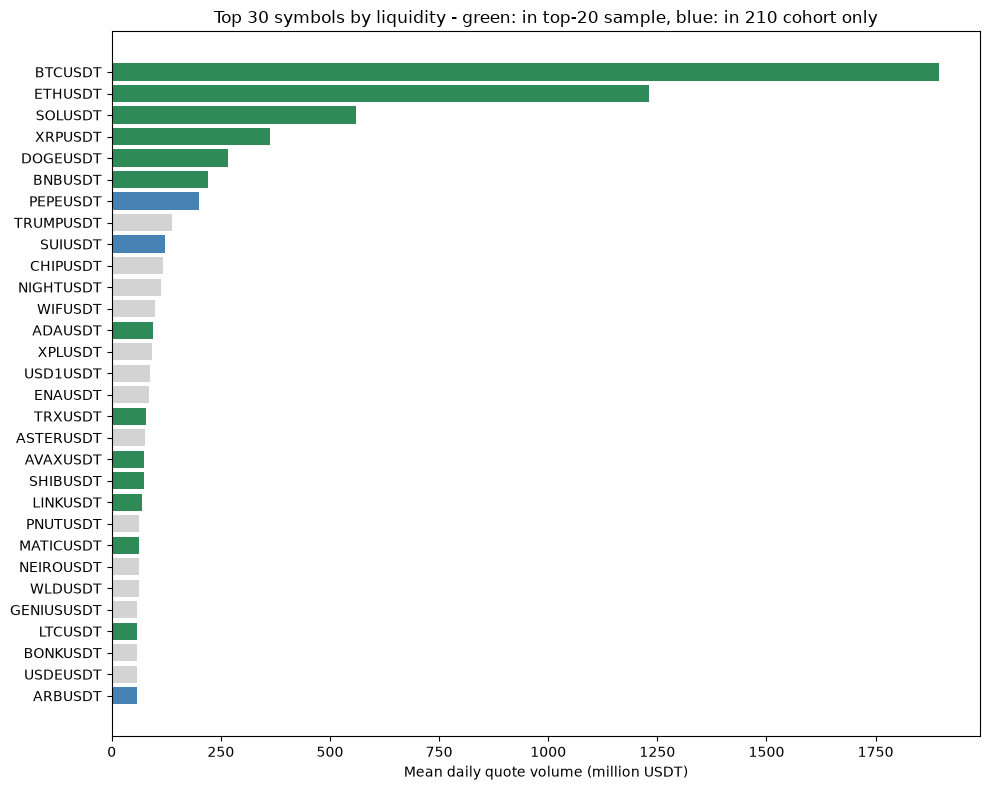

Data-driven top-20 vs configured top-20 sample:
  in ranking but NOT in sample: ['ASTERUSDT', 'CHIPUSDT', 'ENAUSDT', 'NIGHTUSDT', 'PEPEUSDT', 'SUIUSDT', 'TRUMPUSDT', 'USD1USDT', 'WIFUSDT', 'XPLUSDT']
  in sample but NOT in ranking: ['ATOMUSDT', 'BCHUSDT', 'DOTUSDT', 'ETCUSDT', 'FILUSDT', 'LINKUSDT', 'LTCUSDT', 'MATICUSDT', 'UNIUSDT', 'XLMUSDT']


In [4]:
top30 = sym.sort_values("quote_vol_per_day", ascending=False).head(30)
colors = ["seagreen" if t else ("steelblue" if f else "lightgray")
          for t, f in zip(top30.in_top20, top30.in_210)]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top30.symbol[::-1], top30.quote_vol_per_day[::-1] / 1e6, color=colors[::-1])
ax.set_xlabel("Mean daily quote volume (million USDT)")
ax.set_title("Top 30 symbols by liquidity - green: in top-20 sample, blue: in 210 cohort only")
plt.tight_layout()
plt.show()

in20 = set(top30.head(20).symbol)
print("Data-driven top-20 vs configured top-20 sample:")
print("  in ranking but NOT in sample:", sorted(in20 - top20))
print("  in sample but NOT in ranking:", sorted(top20 - in20))

### Findings

1. Trading activity is concentrated in very few coins. BTCUSDT handles about $1.89B of trading per day and ETHUSDT about $1.23B; Bitcoin alone trades more per day than coins #3 to #6 combined (SOL $0.56B, XRP $0.36B, DOGE $0.27B, BNB $0.22B). The typical (median) coin trades only ~$5M/day, so Bitcoin sees roughly 350 times the trading of a typical coin.
2. The originally configured top-20 no longer matches the actual top-20 by trading volume: ten of the twenty differ. Coins listed more recently (PEPE at #7, TRUMP, SUI at #9, WIF, ENA, and several 2025-2026 listings) have overtaken older coins (ATOM, BCH, DOT, ETC, FIL, LINK, LTC, UNI, XLM, and the delisted MATIC). The configured list reflects the market as it was in mid-2023.
3. A process finding: `USD1USDT` appears in the volume-based top-20. It is a stablecoin (a token designed to hold a fixed $1 value, so its price direction is not meaningful to predict) that was listed after the exclusion list was written; the filter needs updating to include USD1 for the full-scale run.
4. The ticker recommendation for the full-scale run is now backed by data: PEPE and SUI combine a complete 3-year history with top-10 trading volume, making them the strongest additions. Very recent listings (TRUMP, CHIP) trade heavily but have short histories, so they would enter with less usable data.

## 2. Market Activity Over Time

Total monthly quote volume and the number of active symbols per month across the whole market.

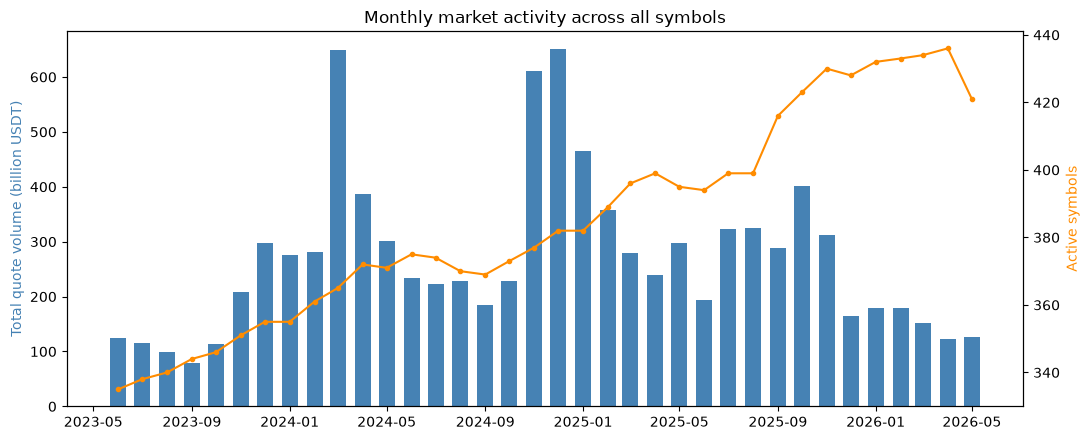

In [5]:
monthly = agg.groupby("month", as_index=False).agg(
    quote_volume=("sum_quote_volume", "sum"), n=("n", "sum"), up_n=("up_n", "sum"))
monthly["active_symbols"] = agg.groupby("month")["symbol"].nunique().values
monthly["up_share"] = monthly.up_n / monthly.n

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(monthly.month, monthly.quote_volume / 1e9, width=20, color="steelblue", label="Quote volume")
ax1.set_ylabel("Total quote volume (billion USDT)", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(monthly.month, monthly.active_symbols, color="darkorange", marker=".", label="Active symbols")
ax2.set_ylabel("Active symbols", color="darkorange")
ax1.set_title("Monthly market activity across all symbols")
plt.tight_layout()
plt.show()

### Findings

1. Market activity comes in large waves. Monthly trading volume ranges from ~$80-125B in quiet months (mid-2023, and again toward 2026) up to ~$650B at the two peaks, March 2024 and November 2024 to January 2025 (the two "bull runs", periods of strongly rising prices and heavy trading). Peak months see about five times the trading of quiet months.
2. The number of traded pairs grew steadily, from ~335 active pairs (2023-06) to ~436 (2026-04): roughly 100 net new listings over three years, with a small dip in 2026-05 as some pairs were removed from the exchange.
3. The period used for final model testing (from 2025-12-14) falls in the quiet phase: monthly trading there is roughly one fifth of the peak months. The models were therefore evaluated under calm-market conditions, which matches the finding in notebook 03 that the models are more accurate when the market moves more.

## 3. Market Regime: Monthly Up-Share

Share of minutes closing above their open, per month, across all symbols. Because flat minutes (no price change) count as "not up", the absolute level sits below 0.5 by construction; the month-to-month swings are the regime signal (see the interpretation note in the findings). The red line marks the start of the modeling test window (2025-12-14).

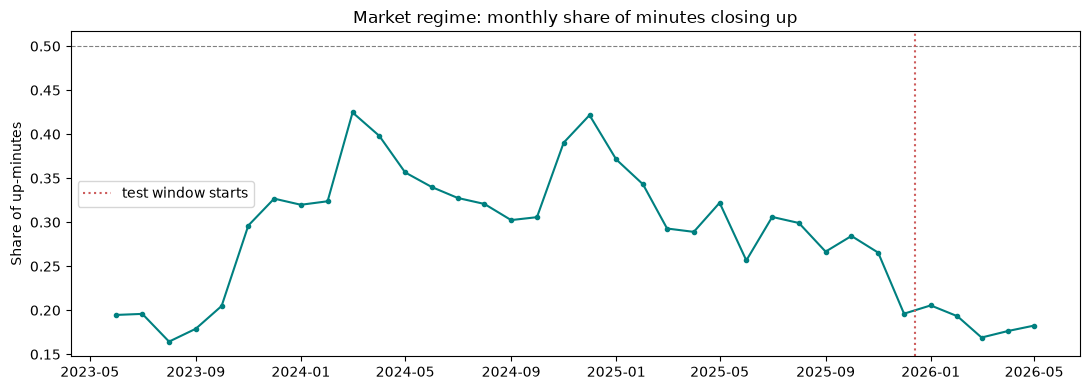

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.month, monthly.up_share, marker=".", color="teal")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(pd.Timestamp("2025-12-14"), color="indianred", linestyle=":", label="test window starts")
ax.set_ylabel("Share of up-minutes")
ax.set_title("Market regime: monthly share of minutes closing up")
ax.legend()
plt.tight_layout()
plt.show()

### Findings

1. **How to read this chart.** The up-share is the fraction of minutes where the price ended higher than it started. Minutes where the price did not move at all count as "not up", and rarely traded coins have many such flat minutes, so the line sits below 0.5 by construction. What matters is how the line rises and falls, not its absolute level.
2. The rises and falls clearly track market cycles: the highest readings, ~0.43 (March 2024) and ~0.42 (December 2024), coincide with the two heavy-trading bull runs from Section 2, while the lowest readings, ~0.16-0.17 (August 2023, April 2026), mark the deepest falling-market phases.
3. The model testing period (from 2025-12-14, red line) sits at ~0.18-0.21, among the weakest readings of the entire three years. This confirms at whole-market scale what the modeling notebooks found on the sample: the models were tested during a pronounced falling market, which is why the simple "always predict down" baseline scored so high (54.35%) and why adjusting the models' decision threshold was important.

## 4. Volatility Landscape and Selection-Bias Check

Distribution of per-symbol intrabar-return volatility across the whole market, with the 210 full-history cohort highlighted. If the cohort's distribution differs sharply from the rest, the full-scale training set is not representative of the whole market, which must be known before interpreting its results.

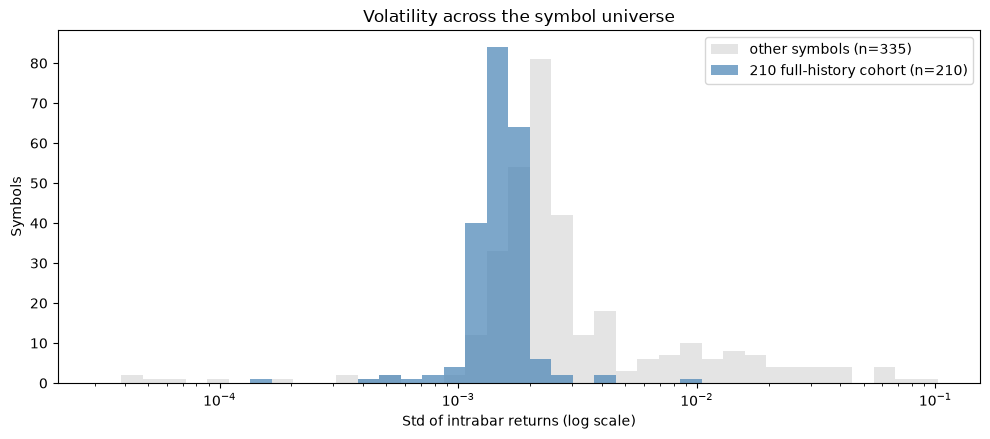

Median per-symbol statistics:
               quote_vol_per_day     std_r  up_share  taker_ratio
other symbols       5.940615e+06  0.002276  0.272400     0.492226
210 cohort          4.172084e+06  0.001512  0.270684     0.493512


In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.logspace(np.log10(max(sym.std_r.min(), 1e-6)), np.log10(sym.std_r.max()), 40)
ax.hist(sym.loc[~sym.in_210, "std_r"], bins=bins, alpha=0.6, label=f"other symbols (n={int((~sym.in_210).sum())})", color="lightgray")
ax.hist(sym.loc[sym.in_210, "std_r"], bins=bins, alpha=0.7, label=f"210 full-history cohort (n={int(sym.in_210.sum())})", color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Std of intrabar returns (log scale)")
ax.set_ylabel("Symbols")
ax.set_title("Volatility across the symbol universe")
ax.legend()
plt.tight_layout()
plt.show()

summary = sym.groupby("in_210")[ ["quote_vol_per_day", "std_r", "up_share", "taker_ratio"] ].median()
summary.index = ["other symbols", "210 cohort"]
print("Median per-symbol statistics:")
print(summary)

### Findings

1. The 210-coin group is much steadier than the rest of the market. Its volatility (how much the price jumps from minute to minute) clusters tightly around a median of 0.0015, while the other 335 coins spread far to the right: their median is 0.0023, and individual coins reach 10 to 50 times the volatility of the 210 group's core.
2. The 210 group is selected by **longevity, not by trading volume**: its median daily trading ($4.2M) is actually slightly below that of the other coins ($5.9M), because the "other" group contains recently listed coins that trade heavily right now. What the 210 group really represents is coins that survived all three years: established, stable pairs.
3. This is a known and accepted selection effect. Models trained on the 210 group describe the behavior of **established, steadier coins**, not of the whole market. Their measured performance should not be assumed to carry over to newly listed, wildly swinging coins, and results are reported with that scope in mind.

## 5. Intraday Seasonality Across the Whole Market

Volume share and taker-buy ratio by UTC hour, aggregated over all symbols and months. This is the population-level justification for the `hour_sin`/`hour_cos` model features.

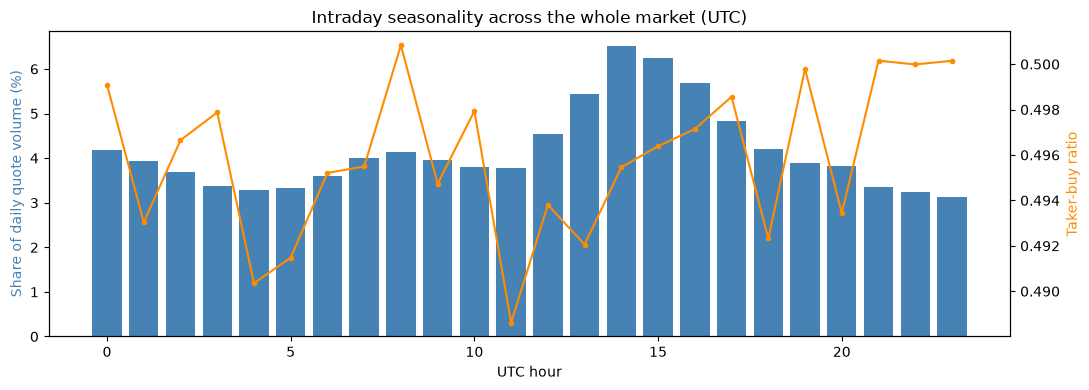

In [8]:
hourly = agg.groupby("hour", as_index=False).agg(
    volume=("sum_volume", "sum"), quote_volume=("sum_quote_volume", "sum"),
    taker_base=("sum_taker_buy_base", "sum"), n=("n", "sum"), up_n=("up_n", "sum"))
hourly["volume_share"] = hourly.quote_volume / hourly.quote_volume.sum()
hourly["taker_ratio"] = hourly.taker_base / hourly.volume

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(hourly.hour, hourly.volume_share * 100, color="steelblue", label="volume share")
ax1.set_xlabel("UTC hour")
ax1.set_ylabel("Share of daily quote volume (%)", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(hourly.hour, hourly.taker_ratio, color="darkorange", marker=".", label="taker-buy ratio")
ax2.set_ylabel("Taker-buy ratio", color="darkorange")
ax1.set_title("Intraday seasonality across the whole market (UTC)")
plt.tight_layout()
plt.show()

### Findings

1. There is a genuine daily rhythm: the busiest hour (14:00 UTC, ~6.5% of the day's trading) sees about **twice** the trading of the quietest (04:00-05:00 UTC, ~3.3%). Activity peaks over 13:00-17:00 UTC, when the US morning overlaps the European afternoon, and is lowest during the late US night and early Asian morning.
2. The taker-buy ratio (the share of trading initiated by buyers, a gauge of buying pressure) varies only between ~0.489 and ~0.501 across the day: a systematic but small pattern. Notably it stays **slightly below 0.5 in almost every hour**, meaning that over these three mostly falling years, sellers were marginally more aggressive than buyers around the clock.
3. Why this matters for the models: the strong daily volume cycle is the whole-market evidence behind the `hour_sin`/`hour_cos` model features. Time of day genuinely changes how the market behaves (mainly how much trading happens, mildly the balance of buying and selling), and encoding the hour as a repeating cycle lets the models use that information.

## 6. Cohort Comparison Summary

Side-by-side medians for the three tiers used in the project: top-20 sample, 210 full-history cohort, and the rest of the market.

In [9]:
def tier(row):
    if row.in_top20:
        return "top-20 sample"
    if row.in_210:
        return "210 cohort (rest)"
    return "other symbols"

sym["tier"] = sym.apply(tier, axis=1)
tier_summary = sym.groupby("tier").agg(
    symbols=("symbol", "count"),
    median_daily_quote_vol=("quote_vol_per_day", "median"),
    median_std_r=("std_r", "median"),
    median_up_share=("up_share", "median"),
    median_taker_ratio=("taker_ratio", "median"),
    total_rows=("n", "sum"),
)
tier_summary

,symbols,median_daily_quote_vol,median_std_r,median_up_share,median_taker_ratio,total_rows
tier,,,,,,
210 cohort (rest),191,3.904266e+06,0.001534,0.259460,0.493515,301443840
other symbols,334,5.935674e+06,0.002277,0.271347,0.492215,267868625
top-20 sample,20,7.164778e+07,0.001234,0.418798,0.493294,30659220


### Findings

The three data tiers line up neatly: more trading goes hand in hand with steadier prices. The top-20 sample is in a class of its own, with median daily trading of $71.6M, about 18 times the rest of the 210 group ($3.9M), the steadiest prices (median volatility 0.0012), and the fewest flat minutes (median up-share 0.42 vs ~0.26-0.27). The remaining 191 coins of the 210 group supply most of the data for the full-scale training run: 301M rows compared with the sample's 31M, roughly a tenfold increase. The 334 "other" coins hold 268M rows but mix short histories with the market's most extreme price swings. The three groups together account for all 600M profiled rows. This ordering supports how the project was designed: build and refine the models on the cleanest, most heavily traded tier; train at full scale on the established group; and deliberately leave the wildest coins out of scope.

## Overall Findings

1. **A few coins dominate the market.** Bitcoin (~$1.89B traded per day) and Ethereum (~$1.23B) tower over everything else; Bitcoin alone trades more per day than coins #3 to #6 combined, and the top-20 group trades about 18 times more than the typical established coin. In practice, "the crypto market" is mostly a few dozen heavily traded pairs.
2. **The original top-20 selection is outdated.** Ranked by actual trading volume, half of the true top-20 are coins listed after the selection was made (PEPE, SUI, TRUMP, WIF, ENA, among others). PEPE and SUI, which combine a full three-year history with top-10 trading volume, are the best-supported additions for the full-scale run, and the newly listed stablecoin USD1 must be added to the exclusion list.
3. **The market moves in large cycles.** Monthly trading peaked twice (March 2024 and November 2024 to January 2025, around $650B per month) and fell to roughly one fifth of that in quiet periods. The months used for final model testing were the quietest, most downward-trending stretch of the entire three years, so the models' measured performance was achieved under difficult conditions.
4. **The 210-coin training set represents established coins, not the whole market.** These are the coins that existed for the full three years: steadier in price, but not more heavily traded than the rest. Model results therefore apply to established coins and should not be assumed to hold for newly listed, wildly swinging coins. This is stated openly as a limitation of the study.
5. **Time of day matters.** The busiest hour (around 14:00 UTC, when the US morning overlaps the European afternoon) sees about twice the trading of the quietest hour, which is why the models include time-of-day features. The balance between buying and selling varies only slightly by hour, leaning a little toward selling across these three mostly falling years.

## References

1. Binance Public Data - historical spot 1-minute k-lines. https://github.com/binance/binance-public-data
2. Zaharia et al. (2016). Apache Spark: A Unified Engine for Big Data Processing. CACM 59(11).